# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Muhammad Dzaky Haidar | 5054251039 |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Load dataset.
# Sesuaikan nama file dengan file dataset yang digunakan.
df = pd.read_csv("insurance.csv")


In [4]:
# Tampilkan beberapa baris pertama dataset.
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# Tampilkan informasi dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
# Periksa missing value.
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [7]:
# Tampilkan statistik deskriptif fitur numerik.
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
# Tampilkan jumlah nilai pada setiap fitur kategorikal.
for col in ['sex', 'smoker', 'region']:
    print(df[col].value_counts())

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


## Lakukan Exploratory Data Analysis (EDA) sederhana yang diperlukan.


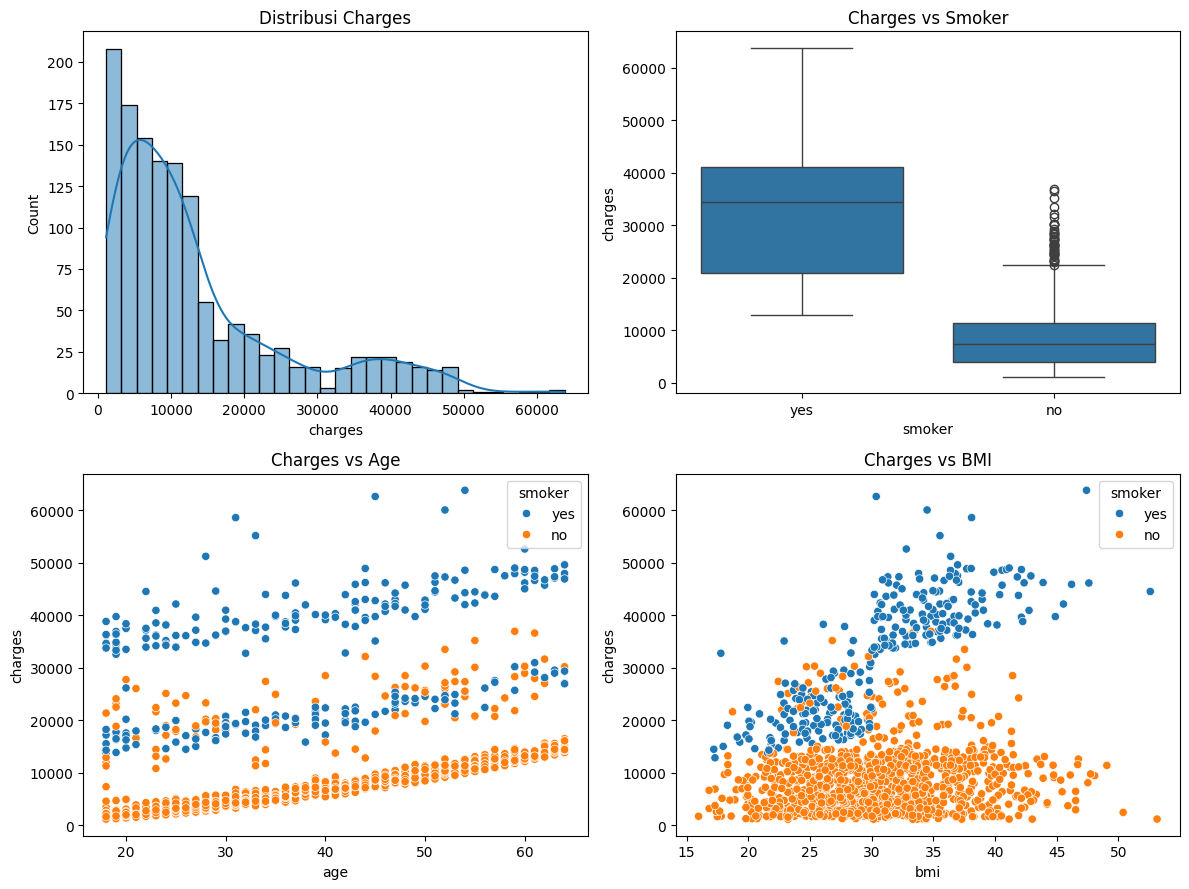

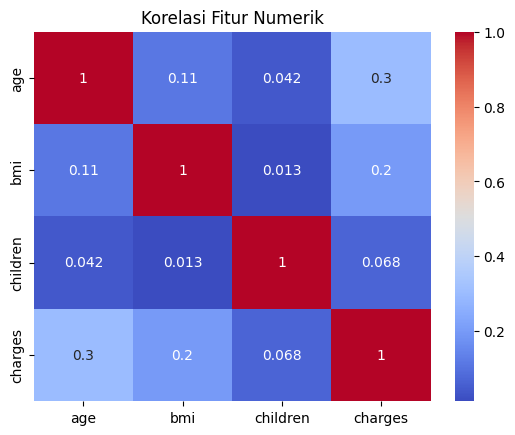

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.histplot(df['charges'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribusi Charges')
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Charges vs Smoker')
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Charges vs Age')
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Charges vs BMI')
plt.tight_layout()
plt.show()

sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur Numerik')
plt.show()


# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [10]:
# Pisahkan fitur (X) dan target (y).
X = df.drop('charges', axis=1)
y = df['charges']

In [11]:
# Identifikasi kolom numerik dan kategorikal.
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)

['age', 'bmi', 'children']
['sex', 'smoker', 'region']


In [12]:
# Bagi data menjadi train set dan test set.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(1070, 6) (268, 6)


In [13]:
# Buat preprocessing untuk fitur numerik dan kategorikal.

# Versi dengan scaling (Linear, Poly, Ridge, Lasso, SVR)
preprocessor_scaled = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

# Versi tanpa scaling (Decision Tree)
preprocessor_tree = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_test_scaled = preprocessor_scaled.transform(X_test)

X_train_tree = preprocessor_tree.fit_transform(X_train)
X_test_tree = preprocessor_tree.transform(X_test)

print(X_train_scaled.shape, X_train_tree.shape)

(1070, 8) (1070, 8)


# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [14]:
# Inisialisasi dan latih Linear Regression.
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [15]:
# Lakukan prediksi pada test set.
y_pred_lr = lr.predict(X_test_scaled)

## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [16]:
# Buat fitur polynomial dan latih model.
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)


LinearRegression()

In [17]:
# Lakukan prediksi pada test set.
y_pred_poly = poly_reg.predict(X_test_poly)


## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [18]:
# Inisialisasi dan latih Ridge Regression.
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

Ridge()

In [19]:
# Lakukan prediksi pada test set.
y_pred_ridge = ridge.predict(X_test_scaled)

## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [20]:
# Inisialisasi dan latih Lasso Regression.
lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

Lasso(max_iter=10000)

In [21]:
# Lakukan prediksi pada test set.
y_pred_lasso = lasso.predict(X_test_scaled)

## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [22]:
# Inisialisasi dan latih Decision Tree Regressor.
dt = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=42)
dt.fit(X_train_tree, y_train)

DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=42)

In [23]:
# Lakukan prediksi pada test set.
y_pred_dt = dt.predict(X_test_tree)

## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [24]:
# Inisialisasi dan latih SVR.
svr = SVR(kernel='rbf', C=100000, gamma=0.1, epsilon=0.1)
svr.fit(X_train_scaled, y_train)

SVR(C=100000, gamma=0.1)

In [25]:
# Lakukan prediksi pada test set.
y_pred_svr = svr.predict(X_test_scaled)

# 4. Evaluasi Model

In [26]:
# Hitung MAE, MSE, RMSE, dan R² untuk setiap model.
# Sajikan hasil dalam satu tabel perbandingan.
predictions = {
    'Linear Regression': y_pred_lr,
    'Polynomial Regression': y_pred_poly,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'Decision Tree': y_pred_dt,
    'SVR': y_pred_svr,
}

results = []
for name, y_pred in predictions.items():
    mse = mean_squared_error(y_test, y_pred)
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,MAE,MSE,RMSE,R2
0,Polynomial Regression,2729.500134,2.071281e+07,4551.132385,0.866583
1,Decision Tree,2697.765431,2.109348e+07,4592.764310,0.864131
2,SVR,1694.569657,2.174911e+07,4663.593830,0.859908
3,Linear Regression,4181.194474,3.359692e+07,5796.284659,0.783593
4,Lasso Regression,4182.219786,3.360573e+07,5797.044759,0.783536
5,Ridge Regression,4193.195353,3.364539e+07,5800.464938,0.783281


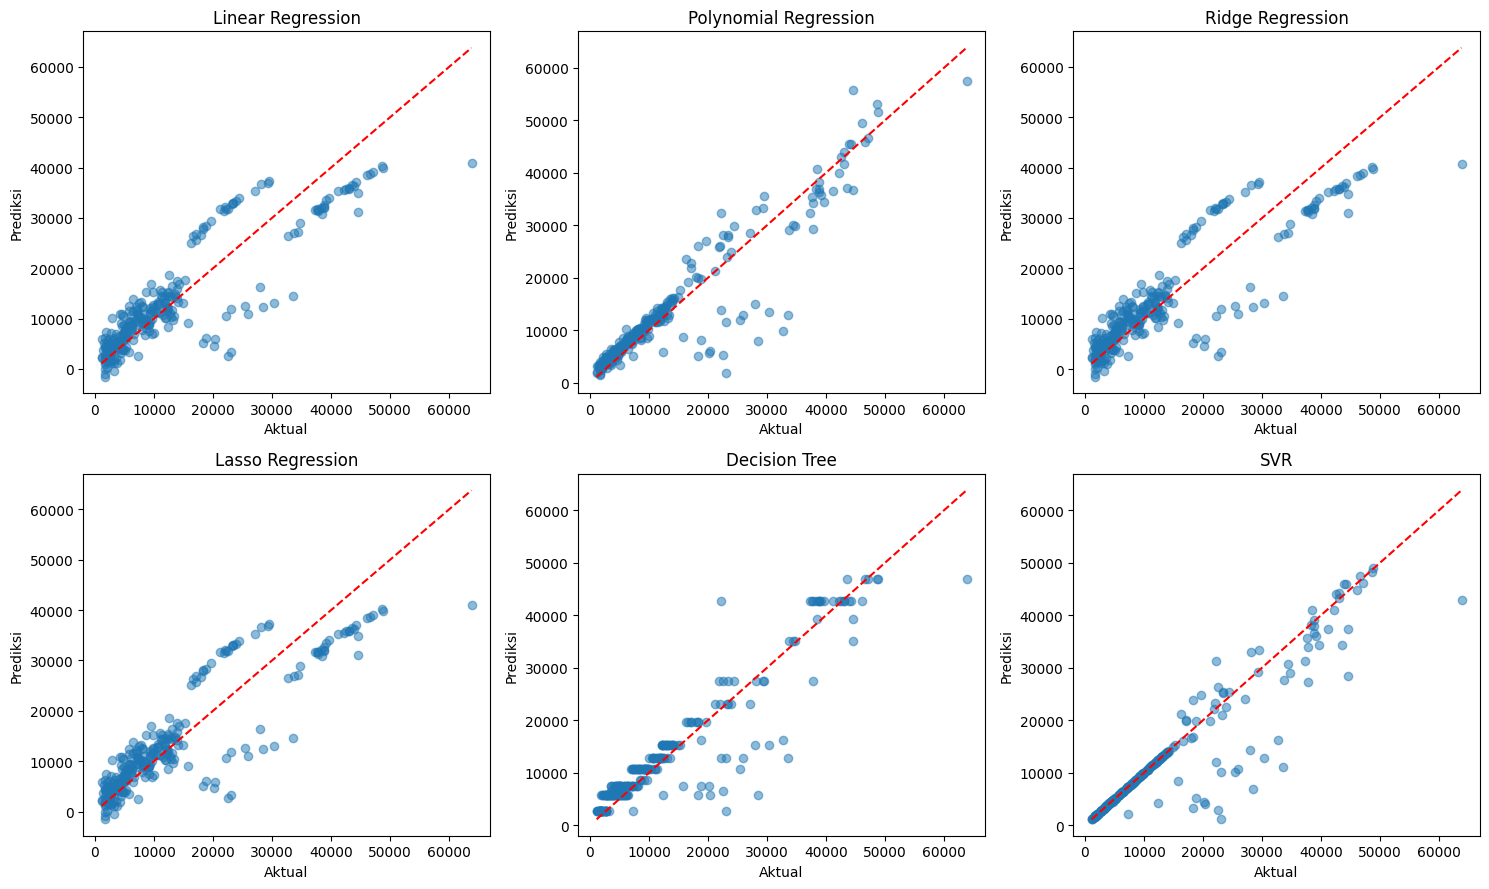

In [27]:
# Buat visualisasi perbandingan nilai aktual dan prediksi jika diperlukan.
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, y_pred) in zip(axes.ravel(), predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_title(name)
    ax.set_xlabel('Aktual')
    ax.set_ylabel('Prediksi')
plt.tight_layout()
plt.show()

# 5. Analisis

#### Perbandingan Hasil Model

| Model | MAE | RMSE | R² |
|-------|-----|------|----|
| Polynomial Regression | 2729.50 | 4551.13 | 0.8666 |
| Decision Tree | 2697.77 | 4592.76 | 0.8641 |
| SVR | 1694.57 | 4663.59 | 0.8599 |
| Linear Regression | 4181.19 | 5796.28 | 0.7836 |
| Lasso Regression | 4182.22 | 5797.04 | 0.7835 |
| Ridge Regression | 4193.20 | 5800.46 | 0.7833 |

#### Analisis Perbandingan Model
- **Polynomial Regression** punya performa terbaik secara keseluruhan: R² tertinggi (0.8666) dan RMSE terendah (4551.13). Ia menangkap hubungan non-linear dan interaksi antar fitur, misalnya efek `smoker` yang diperkuat oleh `bmi` dan `age`.
- **Decision Tree** berada di posisi kedua (R² 0.8641), hampir sama dengan Polynomial. Ia bisa menangkap pola non-linear dan interaksi tanpa asumsi bentuk fungsi, dan tidak butuh scaling.
- **SVR** punya MAE terkecil (1694.57), jauh di bawah model lain. Artinya prediksi pada mayoritas data sangat dekat dengan nilai aktual. RMSE-nya sedikit lebih tinggi, yang menandakan masih ada beberapa kesalahan besar pada data berbiaya tinggi (outlier).
- **Linear, Ridge, dan Lasso** hampir identik (R² ≈ 0.783) dan jauh di bawah tiga model sebelumnya. Hubungan antara fitur dan `charges` tidak sepenuhnya linear, sehingga model linear mengalami underfitting.
- Selisih antara Ridge, Lasso, dan Linear Regression sangat kecil. Dataset hanya punya 8 fitur setelah encoding dan sampelnya cukup banyak, jadi risiko overfitting rendah dan regularisasi tidak banyak membantu.

#### Pengaruh Preprocessing
- **OneHotEncoder (`drop='first'`)** mengubah `sex`, `smoker`, dan `region` menjadi numerik tanpa menimbulkan multikolinearitas (dummy variable trap), yang penting untuk model linear.
- **StandardScaler** wajib untuk SVR karena SVR berbasis jarak (kernel RBF). Ia juga membuat regularisasi Ridge dan Lasso adil di semua fitur, dan menstabilkan Polynomial Features.
- **Decision Tree tanpa scaling** tetap bekerja baik karena pemisahan node berbasis threshold tidak terpengaruh skala fitur.
- Hasil EDA menunjukkan `smoker` adalah fitur paling berpengaruh terhadap `charges`. Perokok punya biaya jauh lebih tinggi, dan sebaran `charges` condong ke kanan (skewed).

#### Pengaruh Parameter
- **Polynomial degree=2** cukup menaikkan R² dari 0.78 ke 0.87 tanpa membuat model terlalu kompleks. Degree yang lebih tinggi berisiko overfitting.
- **Ridge dan Lasso (alpha=1.0)** adalah regularisasi ringan, jadi hasilnya hampir sama dengan Linear Regression.
- **Decision Tree (`max_depth=4`, `min_samples_leaf=10`)** membatasi kompleksitas pohon sehingga tidak overfit dan tetap generalisasi baik.
- **SVR (`C=100000`, `gamma=0.1`)**: nilai `C` besar diperlukan karena target `charges` berskala puluhan ribu. Dengan `C` kecil, SVR cenderung underfit.



# 6. Kesimpulan dan Saran

#### Kesimpulan
- Dari enam model yang diuji, **Polynomial Regression (degree=2)** adalah yang terbaik berdasarkan R² (0.8666) dan RMSE (4551.13).
- **Decision Tree** dan **SVR** hampir setara dengan Polynomial Regression (R² 0.8641 dan 0.8599). SVR unggul pada MAE (1694.57).
- Model linear (**Linear, Ridge, Lasso**) paling lemah (R² ≈ 0.783) karena tidak mampu menangkap hubungan non-linear pada data.
- Regularisasi (Ridge dan Lasso) tidak memberi peningkatan berarti pada dataset ini karena jumlah fitur sedikit dan tidak ada indikasi overfitting.
- Preprocessing (OneHotEncoder dan StandardScaler) berperan penting, terutama untuk SVR dan model berbasis linear.
- Fitur `smoker` adalah faktor dominan penentu biaya medis, diikuti `age` dan `bmi`.

#### Saran
- Lakukan **hyperparameter tuning** dengan `GridSearchCV` atau `RandomizedSearchCV` untuk `degree`, `alpha`, `max_depth`, `min_samples_leaf`, `C`, `gamma`, dan `epsilon`.
- Gunakan **cross-validation** (misalnya 5-fold) supaya evaluasi lebih stabil dan tidak bergantung pada satu pembagian data.
- Tambahkan **feature engineering**, misalnya fitur interaksi `smoker × bmi` atau kategori obesitas (`bmi > 30`), untuk memperbaiki model linear.
- Coba **transformasi log** pada target `charges` untuk mengurangi skewness dan dampak outlier.
- Coba model **ensemble** seperti Random Forest, Gradient Boosting, atau XGBoost, yang umumnya lebih baik untuk data tabular non-linear.
- Tangani **outlier** pada `charges` dan `bmi`, lalu bandingkan performanya.
- Evaluasi lebih dalam dengan **analisis residual**, untuk melihat pola kesalahan pada data berbiaya tinggi.

